# 02 Additional EDA

## 1. Data

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path.cwd().resolve().parent
PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_combined_processed.csv"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"

for p in [FIG_DIR, TAB_DIR]:
    p.mkdir(parents=True, exist_ok=True)

processed = pd.read_csv(PROCESSED_PATH)

processed["age_group"] = pd.Categorical(
    processed["age_group"],
    categories=["<=14", "15", "16", "17", "18+"],
    ordered=True
)

processed["smoking_freq_group"] = pd.Categorical(
    processed["smoking_freq_group"],
    categories=["Light (1~5 days)", "Moderate (6~19 days)", "Frequent (20~30 days)"],
    ordered=True
)

eda = processed[["sad_binary", "smoker_binary", "age_group", "smoking_freq_group", "smoking_freq_score"]].copy()
eda_valid = eda.dropna(subset=["sad_binary", "smoker_binary", "age_group"]).copy()

eda_valid["sad_label"] = eda_valid["sad_binary"].map({0: "No (0)", 1: "Yes (1)"})
eda_valid["smoker_label"] = eda_valid["smoker_binary"].map({0: "Non-smoker (0)", 1: "Current smoker (1)"})

smoker_only = processed.loc[
    processed["smoker_binary"] == 1,
    ["sad_binary", "smoking_freq_group"]
].dropna().copy()

smoker_only["sad_label"] = smoker_only["sad_binary"].map({0: "No (0)", 1: "Yes (1)"})

print("Exploratory EDA n =", eda_valid.shape[0])

Exploratory EDA n = 13120


## 2. Sample size background

In [13]:
sample_size_table = pd.crosstab(
    eda_valid["age_group"],
    eda_valid["smoker_label"]
)

display(sample_size_table)
sample_size_table.to_csv(TAB_DIR / "02_additional_sample_size_by_age_and_smoking.csv")

smoker_label,Current smoker (1),Non-smoker (0)
age_group,,
<=14,142,1167
15,455,2573
16,658,2731
17,757,2618
18+,544,1475


**Observations:** The subgroup sample sizes are clearly larger for non-smokers than for current smokers in every age group. However, each age group still contains a meaningful number of current smokers, so the subgroup comparisons are descriptive and still informative. 

## 3. Smoking Status and SadOrHopeless Across Age Groups

### 3.1 SadOrHopeless Proportion by Age Group and Smoking Status

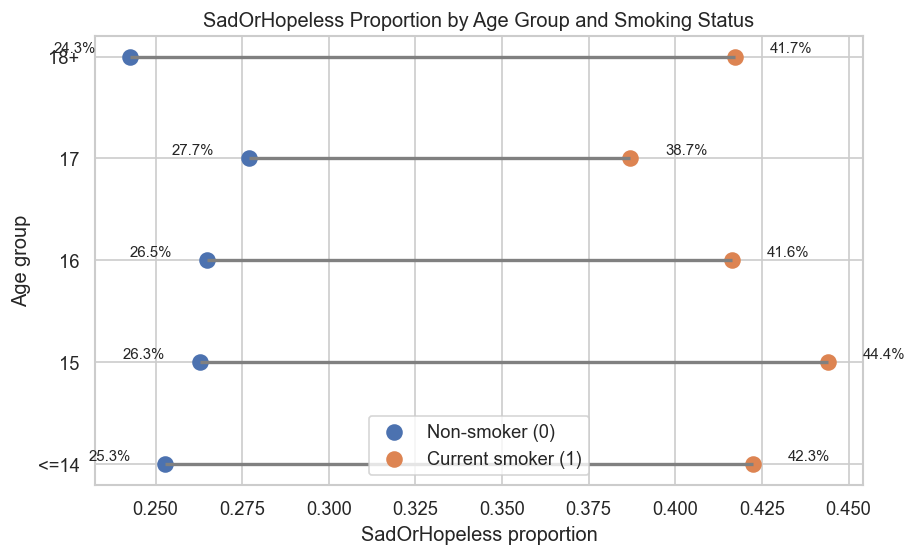

In [14]:
age_smoke_prop = (
    eda_valid.groupby(["age_group", "smoker_label"], observed=False)["sad_binary"]
    .mean()
    .reset_index(name="sad_proportion")
)

dumbbell_df = (
    age_smoke_prop.pivot(index="age_group", columns="smoker_label", values="sad_proportion")
    .reset_index()
)

plt.figure(figsize=(7.8, 4.8))
y = np.arange(len(dumbbell_df))

# 連線
plt.hlines(
    y=y,
    xmin=dumbbell_df["Non-smoker (0)"],
    xmax=dumbbell_df["Current smoker (1)"],
    color="gray",
    linewidth=2
)

# 點
plt.scatter(dumbbell_df["Non-smoker (0)"], y, s=80, label="Non-smoker (0)")
plt.scatter(dumbbell_df["Current smoker (1)"], y, s=80, label="Current smoker (1)")

# 加比例標籤
for i, row in dumbbell_df.iterrows():
    x_non = row["Non-smoker (0)"]
    x_smoke = row["Current smoker (1)"]

    plt.text(x_non - 0.01, i + 0.08, f"{x_non:.1%}", ha="right", va="center", fontsize=9)
    plt.text(x_smoke + 0.01, i + 0.08, f"{x_smoke:.1%}", ha="left", va="center", fontsize=9)

plt.yticks(y, dumbbell_df["age_group"])
plt.xlabel("SadOrHopeless proportion")
plt.ylabel("Age group")
plt.title("SadOrHopeless Proportion by Age Group and Smoking Status")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "02_additional_dumbbell_age_smoking_sad.png", bbox_inches="tight")
plt.show()

**Observations:** In every age group, the current-smoker group has a noticeably higher SadOrHopeless proportion than the non-smoker group. The difference is fairly consistent across age groups: current smokers are generally around 39% to 44%, whereas non-smokers are roughly around 24% to 28%. This suggests that the positive association between smoking status and SadOrHopeless is not limited to only one specific age group.

### 3.2 Gap in SadOrHopeless Proportion Across Age Groups

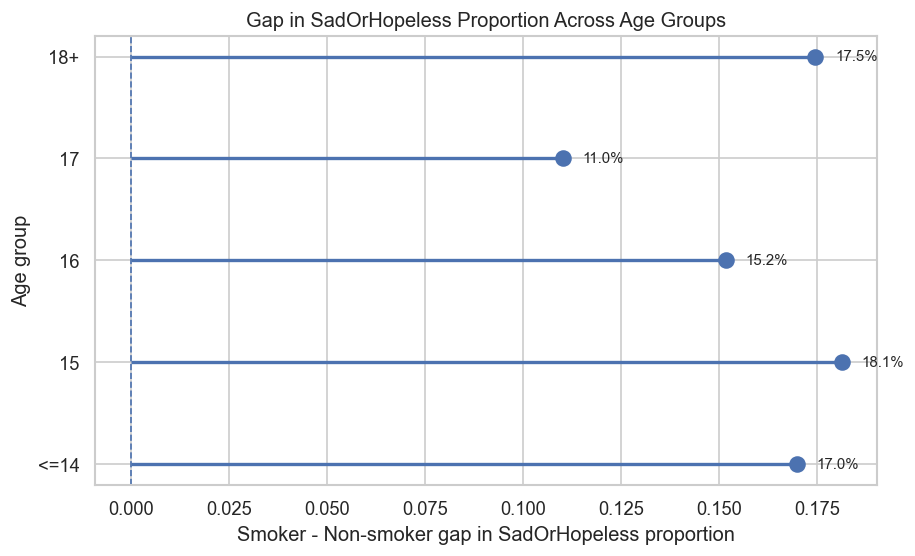

In [15]:
gap_df = dumbbell_df.copy()
gap_df["gap"] = gap_df["Current smoker (1)"] - gap_df["Non-smoker (0)"]

plt.figure(figsize=(7.8, 4.8))
y = np.arange(len(gap_df))

plt.hlines(y=y, xmin=0, xmax=gap_df["gap"], linewidth=2)
plt.scatter(gap_df["gap"], y, s=80)

plt.axvline(0, linestyle="--", linewidth=1)

# 加 gap 標籤
for i, row in gap_df.iterrows():
    x_gap = row["gap"]
    plt.text(x_gap + 0.005, i, f"{x_gap:.1%}", va="center", ha="left", fontsize=9)

plt.yticks(y, gap_df["age_group"])
plt.xlabel("Smoker - Non-smoker gap in SadOrHopeless proportion")
plt.ylabel("Age group")
plt.title("Gap in SadOrHopeless Proportion Across Age Groups")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_additional_lollipop_gap.png", bbox_inches="tight")
plt.show()

**Observations:** The smoker-minus-non-smoker gap is positive in every age group, which means the direction of the association is stable across groups. The gap is largest for age 15 and 18+, and smallest for age 17, but all gaps remain meaningfully above zero. This indicates that the association varies somewhat in strength across age groups, while still pointing in the same overall direction.

## 4. Smoking Frequency Among Current Smokers by SadOrHopeless Status

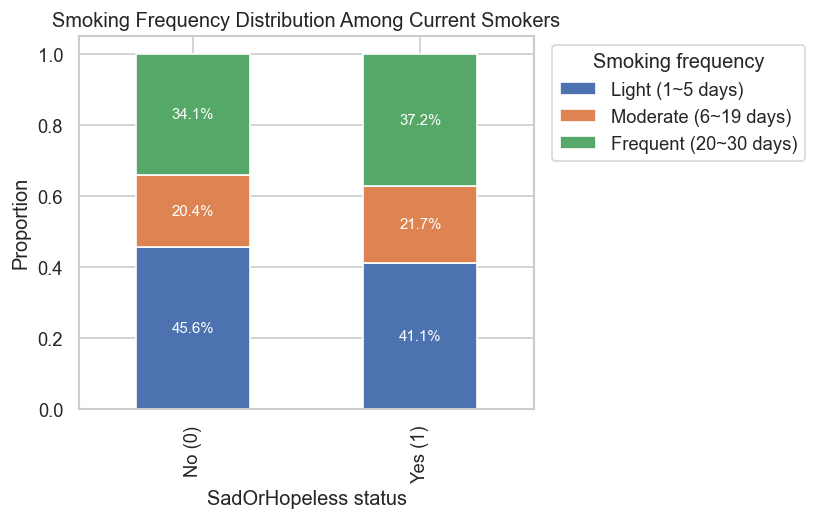

In [16]:
freq_prop_table = pd.crosstab(
    smoker_only["sad_label"],
    smoker_only["smoking_freq_group"],
    normalize="index"
).round(4)

freq_prop_table.to_csv(TAB_DIR / "02_additional_smoker_freq_prop_table.csv")

freq_prop_plot = freq_prop_table.loc[["No (0)", "Yes (1)"]]

ax = freq_prop_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 4.5)
)

plt.title("Smoking Frequency Distribution Among Current Smokers")
plt.xlabel("SadOrHopeless status")
plt.ylabel("Proportion")
plt.legend(title="Smoking frequency", bbox_to_anchor=(1.02, 1), loc="upper left")

# 在每個堆疊區塊中央加上比例文字
for container in ax.containers:
    labels = []
    for v in container.datavalues:
        if v >= 0.03:   # 小於 3% 的區塊不標，避免太擠
            labels.append(f"{v:.1%}")
        else:
            labels.append("")
    ax.bar_label(container, labels=labels, label_type="center", fontsize=9, color="white")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_additional_smoking_frequency_stacked.png", bbox_inches="tight")
plt.show()

**Observations:** Among current smokers, the SadOrHopeless = Yes group appears slightly less concentrated in the light-smoking category and slightly more concentrated in the frequent-smoking category than the SadOrHopeless = No group. The differences are not huge, but they suggest that students reporting SadOrHopeless may also tend to show somewhat heavier smoking patterns. This pattern should be treated as exploratory rather than confirmatory.

## 5. Brief Exploratory Takeaway

Current smokers consistently show a higher SadOrHopeless proportion than non-smokers across age groups, and the size of this difference changes somewhat by age. In addition, among current smokers, students with SadOrHopeless appear to be somewhat more concentrated in higher smoking-frequency categories. Overall, the exploratory EDA suggests a broadly positive association between smoking-related behavior and SadOrHopeless, but these results should still be interpreted as descriptive patterns rather than formal causal evidence.